In [1]:
import lovelyplots
import matplotlib.pyplot as plt
import numpy as np
import scienceplots
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.circuit.library import (
    CXGate,
    RZXGate,
    SwapGate,
    UGate,
    UnitaryGate,
    XXPlusYYGate,
    iSwapGate,
)
from qiskit.circuit.random import random_circuit
from qiskit.quantum_info import Operator, average_gate_fidelity
from qiskit.quantum_info.random import random_unitary
from qiskit.transpiler import (
    InstructionProperties,
    PassManager,
    Target,
    generate_preset_pass_manager,
)
from qiskit.transpiler.passes import Optimize1qGatesDecomposition
from tqdm import tqdm, trange
from weylchamber import c1c2c3

from gulps import logger
from gulps.core.coverage import expected_costs
from gulps.core.invariants import GateInvariants
from gulps.qiskit_ext.synthesis_pass import GulpsDecompositionPass
from gulps.gulps_decomposer import GulpsDecomposer
from gulps.core.isa import ISAInvariants
from gulps.viz.invariant_viz import render_path
from gulps.viz.polytope_viz import _plot_coverage_set

### Usage as a Decomposer

In [2]:
# comment out what you don't want or add your own
isa = [
    # (CXGate(), 1.0, "cx"),
    # (CXGate().power(1 / 2), 1 / 2, "sqrt2cx"),
    # (CXGate().power(1 / 6), 1 / 6, "sqrt6cx"),
    # (iSwapGate(), 1.0, "iswap"),
    # (iSwapGate().power(1 / 2), 1 / 2, "sqrt2iswap"),
    (iSwapGate().power(1 / 4), 1 / 4, "sqrt4iswap"),
    # (iSwapGate().power(1 / 3), 1 / 3, "sqrt3iswap"),
    # (iSwapGate().power(1 / 6), 1 / 6, "sqrt6iswap"),
    # (fsim(np.pi / 2, np.pi / 6).power(1.0), 1.0, "fsim"),
    # (fsim(np.pi / 2, np.pi / 6).power(1 / 2), 1 / 2, "sqrt2fsim"),
    # (fsim(np.pi / 2, np.pi / 6).power(1 / 3), 1 / 3, "sqrt3fsim"),
    # (SwapGate(), 0.0, "swap"),
]
gate_set, costs, names = zip(*isa)
isa = ISAInvariants(gate_set, costs, names, precompute_polytopes=True)
decomposer = GulpsDecomposer(isa=isa)

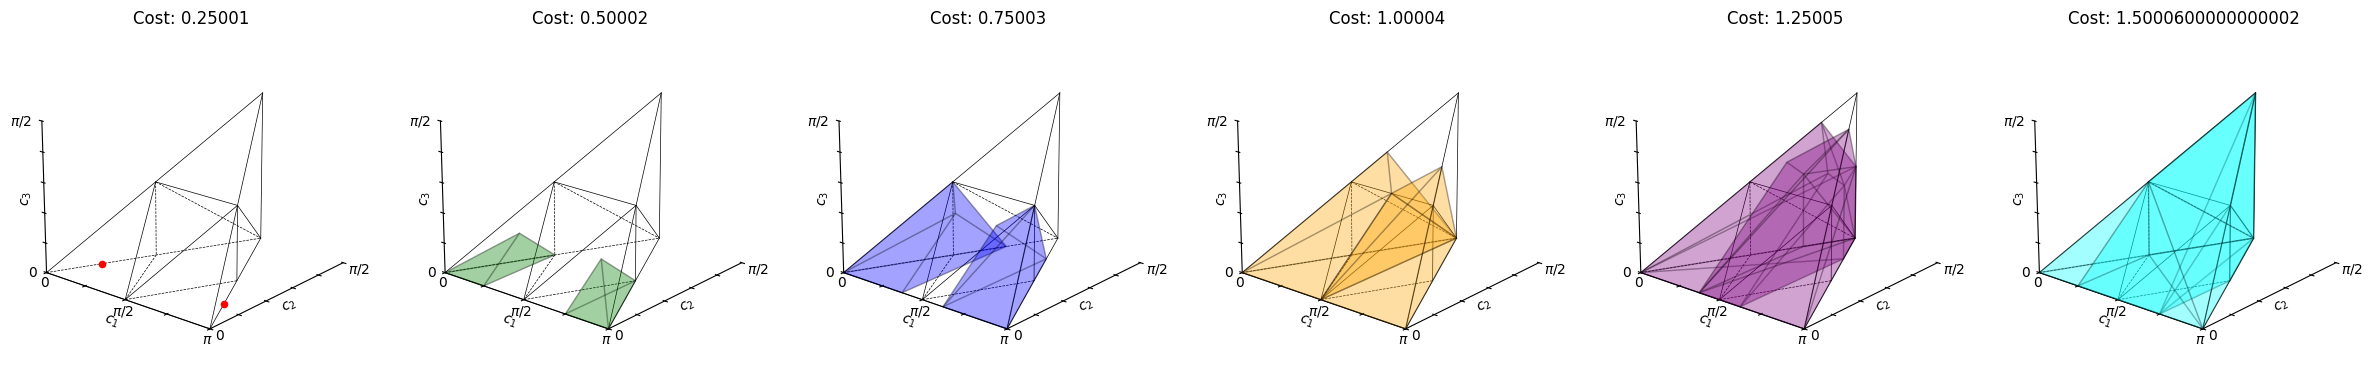

(np.float64(0.9599320617283754), np.float64(3.8395746639269444), np.float64(3.8395746639269444))


In [3]:
# NOTE if this coverage_set looks odd, it is likely due to setting COST_1Q >0
# this is a good idea for sorting equivalent cost sentences but prioritizing less total segments
# TODO reduce to isa coverage set to avoid this issue, prune more expensive + redundant circuit polytopes
# can use polytope.contains(polytope2) method?
# however, it will split up coverage_set into more pieces due to fine grained cost differences
if hasattr(decomposer.isa, "coverage_set"):
    _plot_coverage_set(decomposer.isa.coverage_set)
    print(expected_costs(decomposer.isa.coverage_set))

In [6]:
logger.setLevel("DEBUG")
N = 1_00

# Warm-start to trigger JIT compilation (optional)
_ = decomposer(random_unitary(4, seed=0))

fidelities = []
all_timings = []
failures = 0

for idx in trange(N, desc="Decomposing random unitaries"):
    u = random_unitary(4, seed=idx)
    try:
        v = Operator(decomposer(u))
        fid = average_gate_fidelity(u, v)

        if fid < 1 - 1e-8:
            raise ValueError(f"Fidelity too low: {fid:.8f}")

        fidelities.append(fid)
        all_timings.append(decomposer.last_timing)

    except Exception as e:
        print(f"[WARN] Failed on unitary {idx}: {e}")
        failures += 1

# === Fidelity Statistics ===
fidelities = np.array(fidelities)
print(f"\n✔ Completed {len(fidelities)} successful runs (out of {N})")
print(f"  → Failures: {failures}")
print(f"  → Median Fidelity: {np.median(fidelities)}")
print(f"  → Mean Fidelity:   {np.mean(fidelities)}")
print(f"  → Min Fidelity:    {np.min(fidelities)}")

# === Timing Statistics ===
if all_timings:
    phase_names = list(all_timings[0].keys())
    timing_array = np.array([[t[k] for k in phase_names] for t in all_timings])

    print("\nAverage phase durations:")
    for k, mean_time in zip(phase_names, timing_array.mean(axis=0)):
        print(f"  {k:>10}: {mean_time:.4f} s")

    print(f"\n  Total average time: {timing_array.sum(axis=1).mean():.4f} s")
else:
    print("No successful timings collected.")

[gulps.gulps_decomposer] DEBUG: Sentence: ['sqrt4iswap', 'sqrt4iswap', 'sqrt4iswap', 'sqrt4iswap']
[gulps.gulps_decomposer] DEBUG: Intermediates: [(np.float64(0.12500000000000003), np.float64(0.0), np.float64(0.0), np.float64(-0.12500000000000003)), (np.float64(0.1352054759040596), np.float64(0.10762581491501078), np.float64(-0.0), np.float64(-0.24283129081907037)), (np.float64(0.2326258149150108), np.float64(0.1352054759040596), np.float64(-0.09915559242776284), np.float64(-0.26867569839130756)), (np.float64(0.2326258149150108), np.float64(0.1352054759040596), np.float64(0.025844407572237188), np.float64(-0.39367569839130756))]
[gulps.synthesis.jax_lm] DEBUG: Segment solver SUCCESS [easy attempt 1] (residual norm=2.23e-12, nfev=26) in 0.010s
[gulps.synthesis.segments_solver] DEBUG: [segment 1] constructed makh: [0.37712399328082635, 0.11738033406625081, 1.4853058857173036]
[gulps.synthesis.segments_solver] DEBUG: [segment 1] target makh: [0.3771239932813348, 0.11738033406632818, 1.485

[gulps.synthesis.segments_solver] DEBUG: [segment 2] target rho(makhlin): [0.1322460652659186, 0.030825070474991733, 0.9683970704695924]
[gulps.synthesis.jax_lm] DEBUG: Segment solver SUCCESS [easy attempt 1] (residual norm=2.78e-16, nfev=128) in 0.028s
[gulps.synthesis.segments_solver] DEBUG: [segment 3] constructed makh: [-0.04461835680748851, 0.15625415296750264, -0.19750002700913283]
[gulps.synthesis.segments_solver] DEBUG: [segment 3] target makh: [-0.04461835680748895, 0.15625415296750253, -0.19750002700913466]
[gulps.synthesis.segments_solver] DEBUG: [segment 3] constructed weyl: [0.36783129 0.25847022 0.16104988]
[gulps.synthesis.segments_solver] DEBUG: [segment 3] target weyl: [0.36783129 0.25847022 0.16104988]
[gulps.synthesis.segments_solver] DEBUG: [segment 3] construct rho(makhlin): [-0.04461835680748858, 0.1562541529675025, -0.1975000270091334]
[gulps.synthesis.segments_solver] DEBUG: [segment 3] target rho(makhlin): [-0.044618356807488664, 0.1562541529675028, -0.19750002

[WARN] Failed on unitary 20: Cannot recover local equivalence; Weyl differences [3.17293375e-05 3.17300000e-05 7.10542736e-15]


[gulps.gulps_decomposer] DEBUG: Sentence: ['sqrt4iswap', 'sqrt4iswap', 'sqrt4iswap']
[gulps.gulps_decomposer] DEBUG: Intermediates: [(np.float64(0.12500000000000003), np.float64(0.0), np.float64(0.0), np.float64(-0.12500000000000003)), (np.float64(0.1245452884611433), np.float64(0.04054529673834229), np.float64(-0.0), np.float64(-0.16509058519948558)), (np.float64(0.20006835392509856), np.float64(0.04947693453604473), np.float64(0.04054529673834229), np.float64(-0.2900905851994856))]
[gulps.synthesis.jax_lm] DEBUG: Segment solver SUCCESS [easy attempt 1] (residual norm=3.18e-10, nfev=18) in 0.006s
[gulps.synthesis.segments_solver] DEBUG: [segment 1] constructed makh: [0.6335969997662945, 0.03824831731031412, 2.1854009693399954]
[gulps.synthesis.segments_solver] DEBUG: [segment 1] target makh: [0.6335969998358704, 0.03824831731241285, 2.1854009693122673]
[gulps.synthesis.segments_solver] DEBUG: [segment 1] constructed weyl: [0.16509059 0.12454529 0.0405453 ]
[gulps.synthesis.segments_so

[WARN] Failed on unitary 25: Cannot recover local equivalence; Weyl differences [5.43703128e-05 5.43747626e-05 5.41788836e-14]


...

[WARN] Failed on unitary 63: Cannot recover local equivalence; Weyl differences [4.47982846e-05 4.47994658e-05 6.21724894e-15]


[gulps.synthesis.jax_lm] DEBUG: Segment solver SUCCESS [easy attempt 1] (residual norm=3.62e-10, nfev=15) in 0.007s
[gulps.synthesis.segments_solver] DEBUG: [segment 1] constructed makh: [0.7091062735279875, -3.075431289171463e-17, 2.3683379250998353]
[gulps.synthesis.segments_solver] DEBUG: [segment 1] target makh: [0.7091062735926518, 0.0, 2.3683379250726064]
[gulps.synthesis.segments_solver] DEBUG: [segment 1] constructed weyl: [ 1.30086348e-01  1.30078731e-01 -1.41357940e-16]
[gulps.synthesis.segments_solver] DEBUG: [segment 1] target weyl: [ 0.13008254  0.13008254 -0.        ]
[gulps.synthesis.segments_solver] DEBUG: [segment 1] construct rho(makhlin): [0.7091062735279865, -1.0087193137227498e-16, 2.368337925099832]
[gulps.synthesis.segments_solver] DEBUG: [segment 1] target rho(makhlin): [0.7091062735926514, 3.936330559243534e-17, 2.3683379250726055]
[gulps.synthesis.jax_lm] DEBUG: Segment solver SUCCESS [easy attempt 1] (residual norm=1.12e-14, nfev=128) in 0.011s
[gulps.synthes

[WARN] Failed on unitary 76: Cannot recover local equivalence; Weyl differences [2.68964850e-05 2.68982180e-05 3.10862447e-14]


[gulps.synthesis.jax_lm] DEBUG: Segment solver SUCCESS [easy attempt 2] (residual norm=2.97e-10, nfev=49) in 0.014s
[gulps.synthesis.segments_solver] DEBUG: [segment 1] constructed makh: [0.33074801046837177, 1.665654162453519e-17, 1.300427822784838]
[gulps.synthesis.segments_solver] DEBUG: [segment 1] target makh: [0.3307480104884976, 1.8360202829664632e-17, 1.30042782277905]
[gulps.synthesis.segments_solver] DEBUG: [segment 1] constructed weyl: [0.22600338 0.22600038 0.        ]
[gulps.synthesis.segments_solver] DEBUG: [segment 1] target weyl: [ 0.22600188  0.22600188 -0.        ]
[gulps.synthesis.segments_solver] DEBUG: [segment 1] construct rho(makhlin): [0.33074801046837154, 0.0, 1.3004278227848367]
[gulps.synthesis.segments_solver] DEBUG: [segment 1] target rho(makhlin): [0.33074801048849733, -3.6720405659329226e-17, 1.3004278227790493]
[gulps.synthesis.jax_lm] DEBUG: Segment solver SUCCESS [easy attempt 1] (residual norm=4.14e-10, nfev=128) in 0.013s
[gulps.synthesis.segments_so


✔ Completed 94 successful runs (out of 100)
  → Failures: 6
  → Median Fidelity: 0.9999999999995887
  → Mean Fidelity:   0.9999999999914939
  → Min Fidelity:    0.9999999999085698

Average phase durations:
          lp: 0.0047 s
     numeric: 0.0723 s
      stitch: 0.0093 s

  Total average time: 0.0863 s


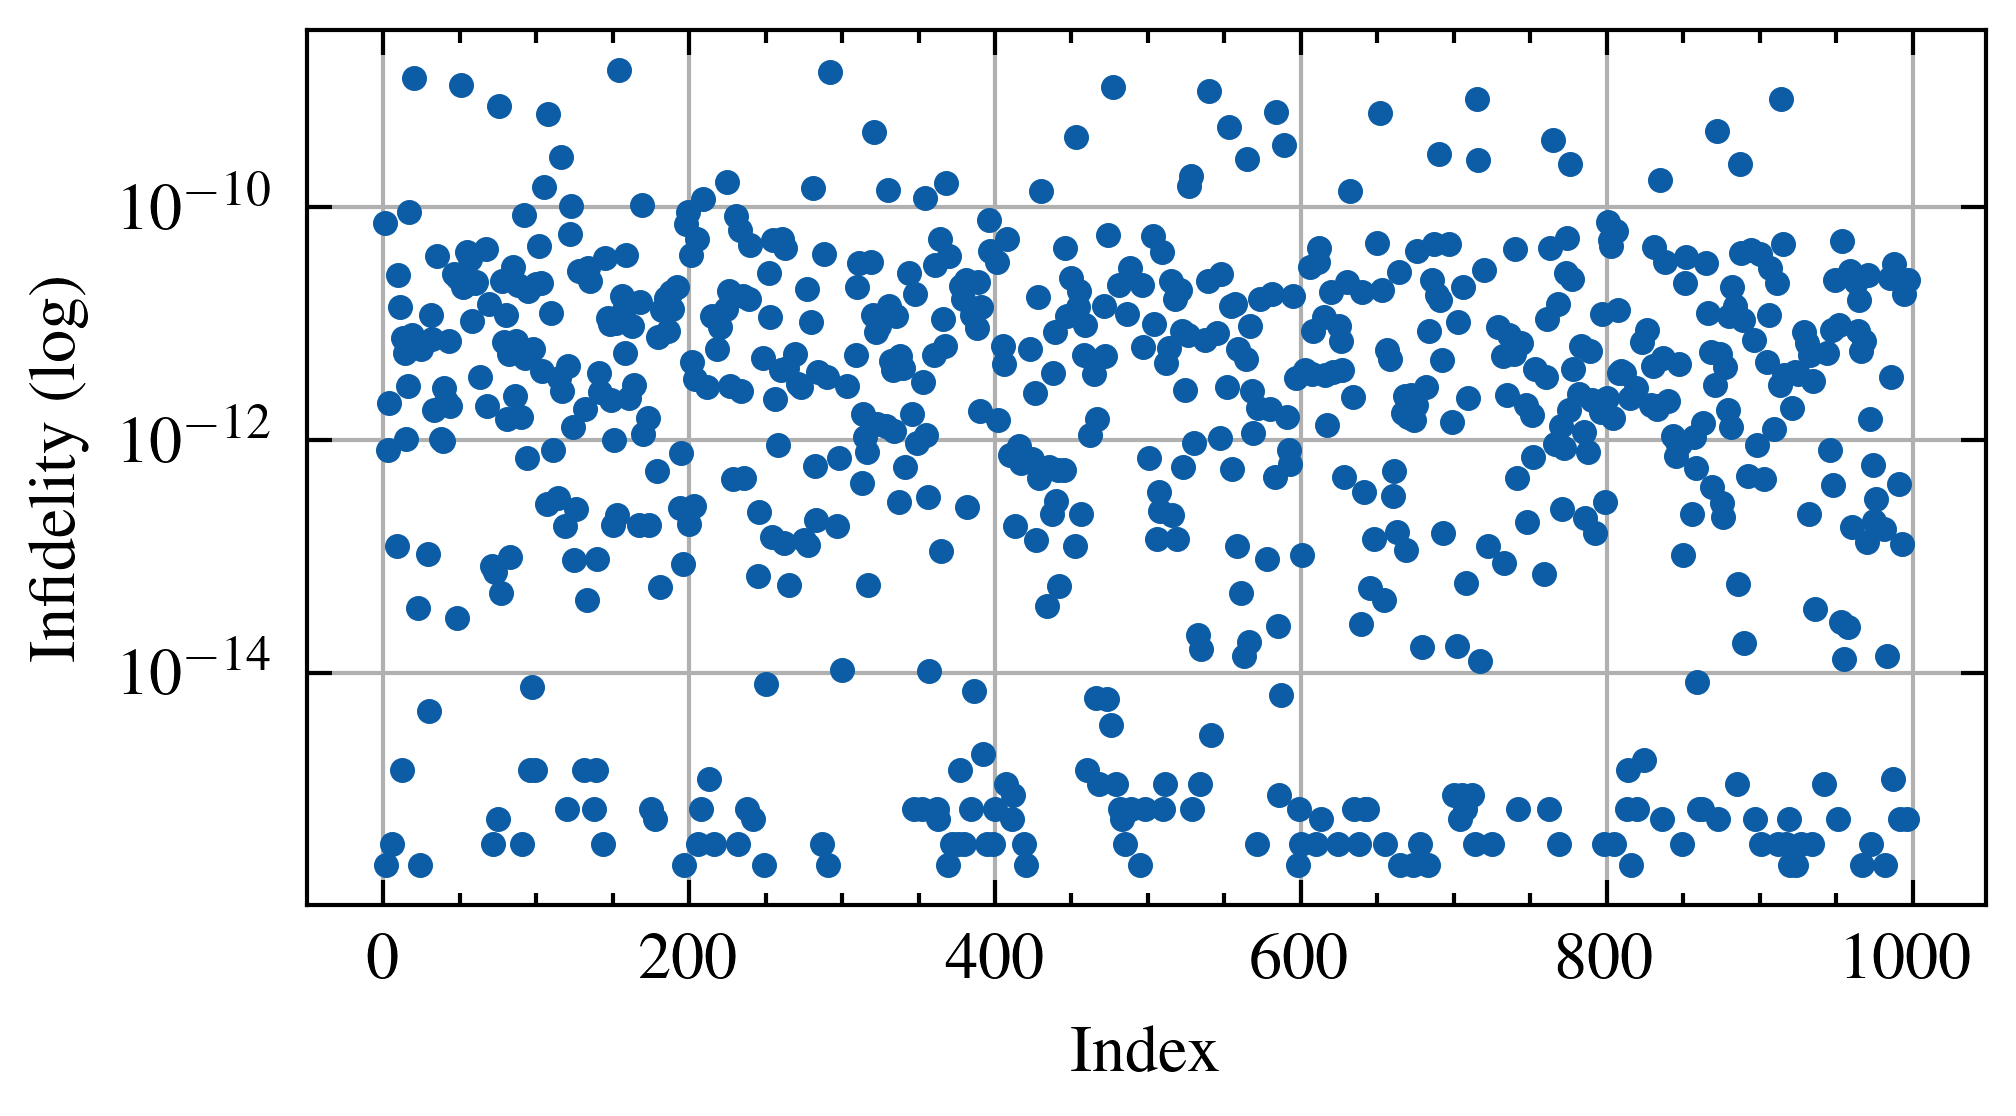

In [ ]:
# make a plot for the fidelities
with plt.style.context(["ieee", "science", "use_mathtext"]):
    fig, ax = plt.subplots(figsize=(3.5, 2))
    ax.plot(1 - fidelities, marker="o", markersize=2, linestyle="None")
    ax.set_xlabel("Index")
    ax.set_ylabel("Infidelity (log)")
    ax.set_yscale("log")
    ax.grid(True)
    plt.tight_layout()
    plt.show()

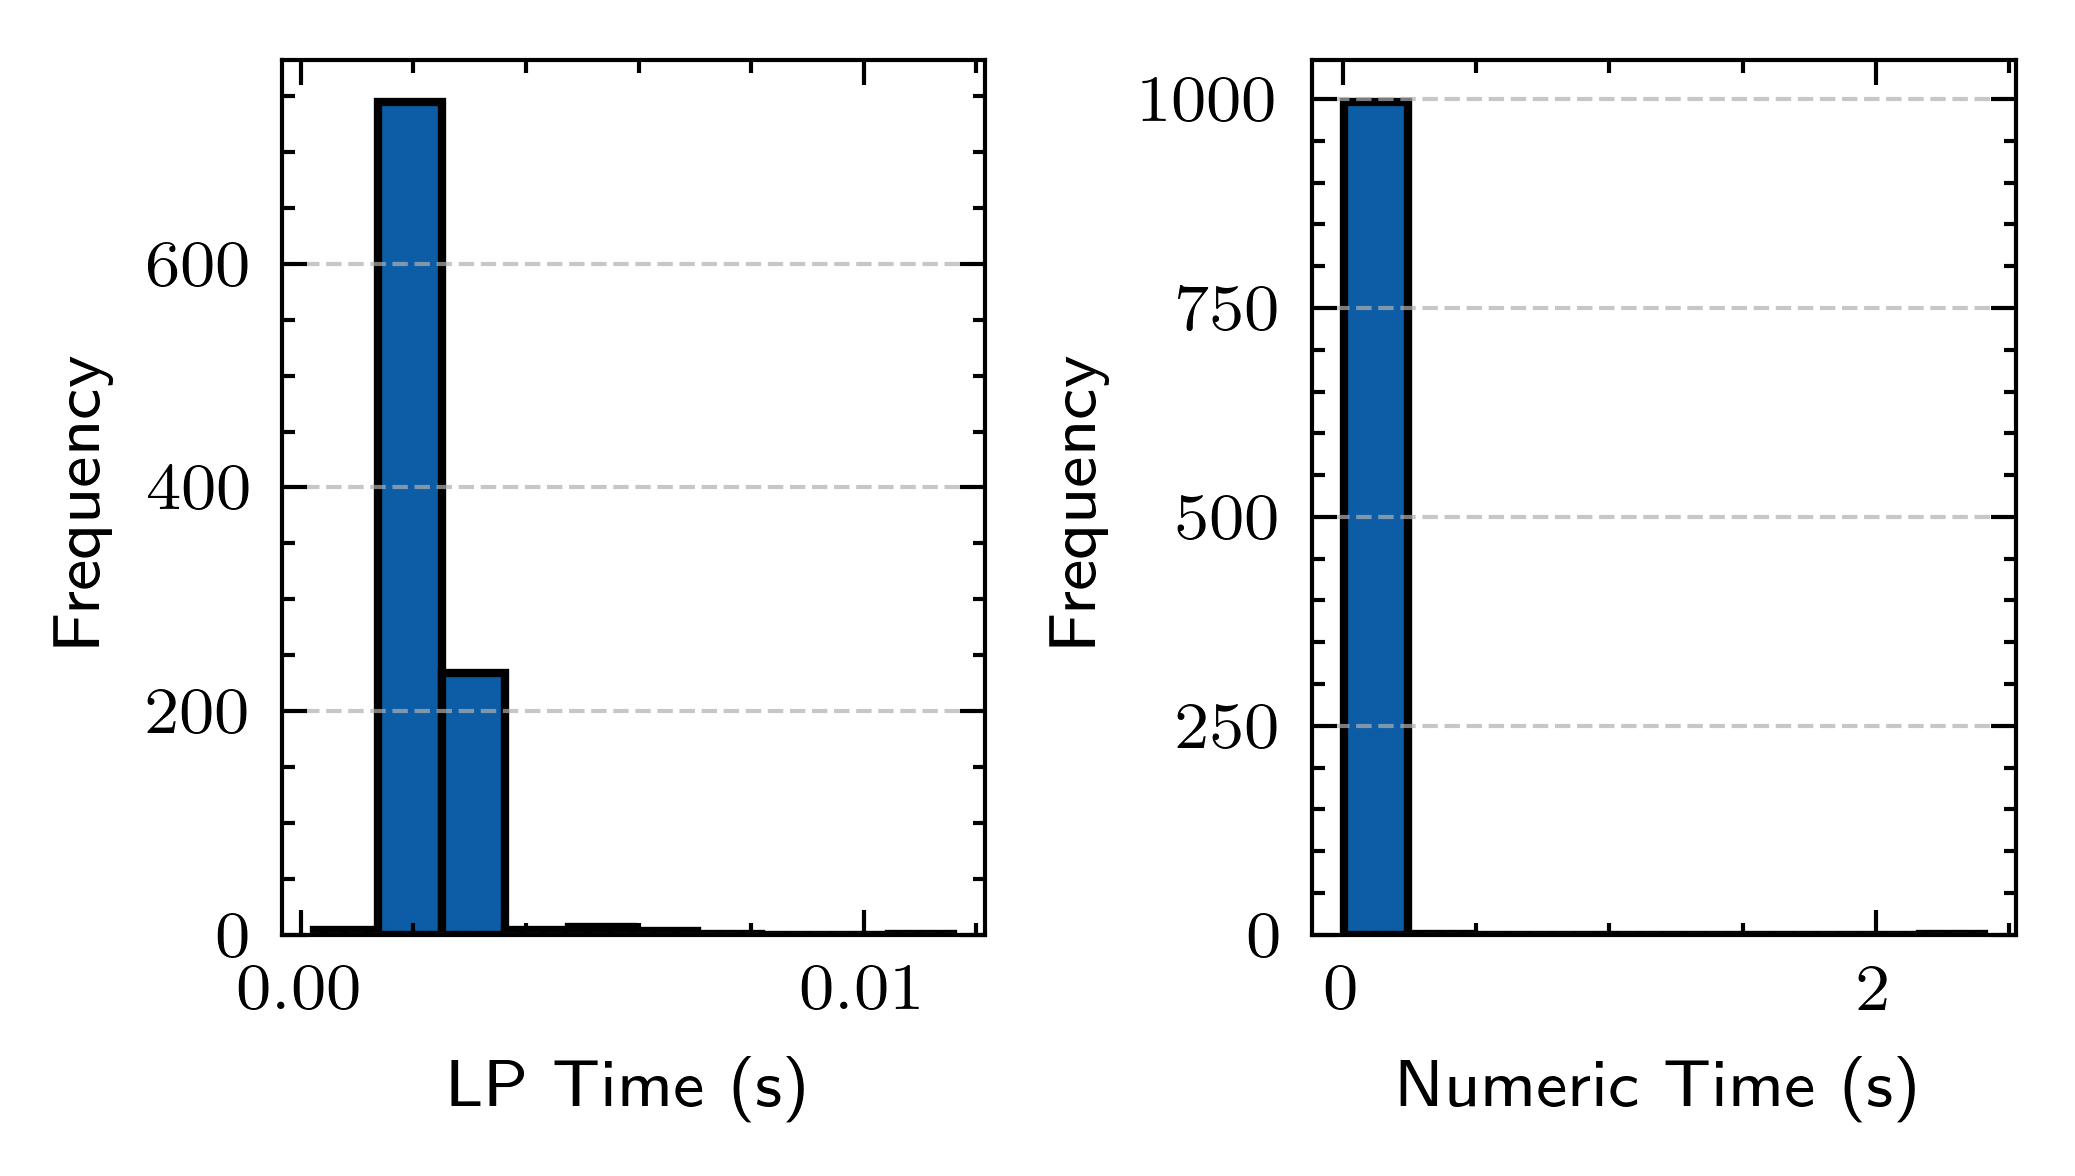

In [ ]:
# Convert list of dicts to lists of values
lp_times = [d["lp"] for d in all_timings]
numeric_times = [d["numeric"] for d in all_timings]
stitch_times = [d["stitch"] for d in all_timings]

with plt.style.context(["ieee", "science", "use_mathtext"]):
    fig, axes = plt.subplots(1, 2, figsize=(3.5, 2))

    axes[0].set_xlabel("LP Time (s)")
    axes[0].set_ylabel("Frequency")
    axes[0].grid(axis="y", linestyle="--", alpha=0.7)
    axes[0].hist(lp_times, edgecolor="black")

    axes[1].set_xlabel("Numeric Time (s)")
    axes[1].set_ylabel("Frequency")
    axes[1].grid(axis="y", linestyle="--", alpha=0.7)
    axes[1].hist(numeric_times, edgecolor="black")

    fig.tight_layout()
plt.show()

#### Inspecting the pieces

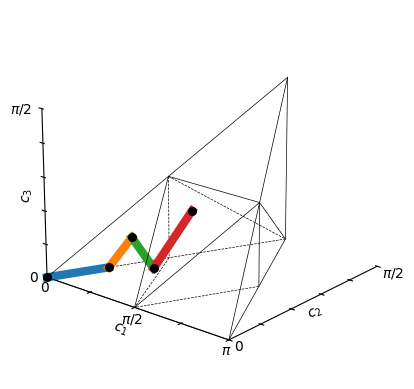

In [ ]:
example_input = random_unitary(4, seed=0)
example_sentence, example_intermediates = decomposer._best_decomposition(
    target_inv=GateInvariants.from_unitary(example_input, enforce_alcove=True)
)
render_path(example_intermediates);

In [ ]:
# NOTE, try with/out this reflection.
# the Decomposer has interal logic to handle this.
# example_intermediates = [x.rho_reflect for x in example_intermediates]

example_segment_solutions = decomposer._numerics._synthesize_segments(
    example_sentence, example_intermediates
)
print("Segment solutions:", example_segment_solutions)

# Recover unitary equivalence by promoting local equivalence
ret = decomposer._numerics._stitch_segments(
    example_sentence, example_intermediates, example_segment_solutions
)
U, V = c1c2c3(example_input), c1c2c3(Operator(ret).data)
print("Input unitary weyl invariants:", U)
print("Output unitary weyl invariants:", V)

ret.draw("mpl")

AttributeError: 'GulpsDecomposer' object has no attribute '_numerics'

### Usage as a TransformationPass 
This works but not ideally due to the hashing behavior. There are some work arounds for caching attributes for passes, see SolovayKitaev pass for example.

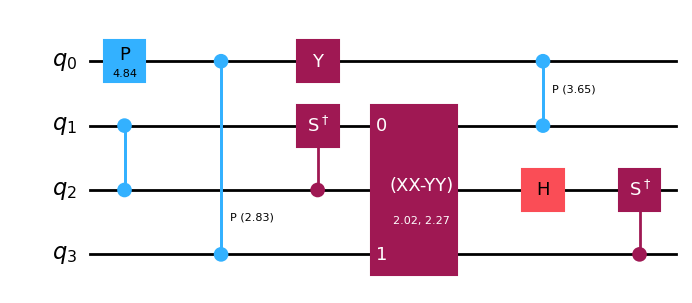

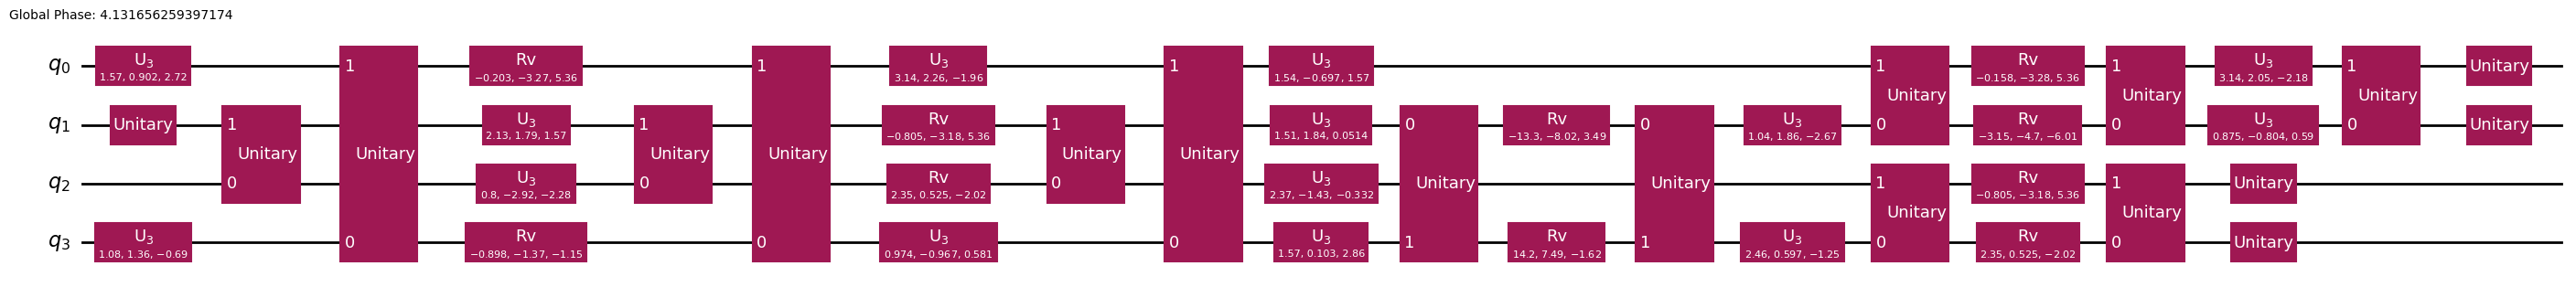

In [ ]:
input_qc = random_circuit(
    4, 4, max_operands=2, num_operand_distribution={1: 0.2, 2: 0.8}
)
display(input_qc.draw("mpl"))

# FIXME hashable?
hashable_gate_set = [x.to_matrix() for x in gate_set]
pm = PassManager(
    [
        GulpsDecompositionPass(hashable_gate_set, costs),
        Optimize1qGatesDecomposition(),
    ]
)
output_qc = pm.run(input_qc)
output_qc.draw("mpl", fold=-1)

### Usage as a Unitary Synthesis Plugin (Broken)

In [ ]:
# # check that the plugin is installed
# from qiskit.transpiler.passes.synthesis import unitary_synthesis_plugin_names

# unitary_synthesis_plugin_names()

In [ ]:
# # create some mock hetereogeneous ISA backend
# target = Target()

# target.add_instruction(
#     RZXGate(np.pi / 2),
#     {
#         (0, 1): InstructionProperties(
#             duration=100,
#             error=0.01,
#         )
#     },
#     name="cx",
# )
# target.add_instruction(
#     RZXGate(np.pi / 4),
#     {
#         (0, 1): InstructionProperties(
#             duration=50,
#             error=0.05,
#         )
#     },
#     name="scx",
# )

# target.add_instruction(
#     XXPlusYYGate(np.pi),
#     {
#         (0, 1): InstructionProperties(
#             duration=200,
#             error=0.02,
#         )
#     },
#     name="iswap",
# )
# target.add_instruction(
#     XXPlusYYGate(np.pi / 2),
#     {
#         (0, 1): InstructionProperties(
#             duration=100,
#             error=0.01,
#         )
#     },
#     name="siswap",
# )

# theta = Parameter("theta")
# phi = Parameter("phi")
# lam = Parameter("lambda")
# u_props = {
#     (0,): InstructionProperties(duration=0, error=0),
#     (1,): InstructionProperties(duration=0, error=0),
# }
# target.add_instruction(UGate(theta, phi, lam), u_props)

In [ ]:
# circuit = QuantumCircuit(2)
# # circuit.cx(0, 1)
# circuit.append(UnitaryGate(Operator(CXGate())), [0, 1])

# pass_manager = generate_preset_pass_manager(
#     optimization_level=3,
#     target=target,
#     translation_method="synthesis",
#     unitary_synthesis_method="gulps",
# )

# out = pass_manager.run(circuit)
# out.draw("mpl")